<a href="https://colab.research.google.com/github/gitmystuff/INFO5810/blob/main/Module_06-Nodes_and_Edges/Nodes_and_Edges_Graph_Databases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nodes and Edges: Graph Databases

Your Name

## Getting Started

* Colab - get notebook from gitmystuff INFO5810 repository
* Save a Copy in Drive
* Remove Copy of
* Edit your name in the cell above and the filename
* Clean up Colab Notebooks folder
* Submit shared link

## The Geometry of Networks

Almost everything you use is a network: friends on social media, roads on a map, links between web pages. A network is just a set of things (**nodes**) and the connections between them (**edges**).

This notebook asks two questions:

1. What *is* a graph, and why do people build whole databases just to store one?
2. What can the *shape* of a network tell us that a plain list of connections cannot?

This module comes in two parts.

| | **Part A (this notebook)** | **Part B** |
|---|---|---|
| Question | What *is* a graph, and what can its geometry tell us? | How does a real graph database store and query one? |
| Tools | NetworkX, NumPy, scikit-learn (all preinstalled in Colab) | Neo4j, Cypher, Graph Data Science |
| Setup | none | local install, with its own walkthrough |

**The frame we keep using.** Since Module 1, a row of data has been a point in space, and knowledge discovery has meant studying the shape of the cloud: distances, directions, and the axes (our feature measuring sticks) we measure them along. A graph is one more place where that frame pays off, and the twist here is that we will trade the original axes for better ones. So in this notebook:

- a node's neighborhood is a **point** (a row of the adjacency matrix),
- shortest paths define a **distance**,
- importance is a **coordinate along an eigenvector**,
- and groups of tightly connected nodes (called **communities**) are **regions** of a space, which a label can only summarize.

**Labels: a summary or a check.** Community-detection software (we meet a popular method, Louvain, in Part 6) reads a network and hands back a group name for every node, like "member 5 is in community 2." That name is a **summary**: one word standing in for a whole pattern of who sits close to whom. Other times we already know the answer, like the species of each Iris flower. That known label is a **check**: we hold it back, look for structure using only the measurements (which flowers sit close together), and only then see whether the groups we found line up with the species. What we never do is start from a label and work forward.

**The story in nine steps.**

0. **A cold open.** A famous family, and three ways to measure who matters in a network.
1. **What a graph is.** Nodes, edges, properties, and how a sentence becomes a graph.
2. **Why graph databases exist.** The cost of asking "who is nearby?"
3. **Geometry.** Every node is a point, and every pair of nodes has a distance.
4. **PageRank.** Importance, found by letting a wanderer loose on the network.
5. **The Laplacian.** One number per member that reveals the two sides of a network.
6. **Louvain.** A second way to find groups, and what a group label hides.
7. **Building graphs from data.** Turning flowers and variables into networks.
8. **Prompting AI for graph work.** The quiet bug that makes correct-looking code wrong.

**Learning goals.** By the end you should be able to:

1. Describe a graph as data: nodes, edges, properties, and how triples differ from a property graph.
2. Explain why graph databases exist.
3. Treat a graph as geometry: adjacency rows as points, shortest paths as a metric, PageRank and Laplacian eigenvectors as coordinates.
4. Read a community-detection result as a summary of geometry, and say what a hard label hides.
5. Write a structured prompt for graph code and catch the bugs AI-generated graph code tends to hide.
6. Use NetworkX to build, draw, and measure a graph.

As always: **overview, not mastery.** You will not memorize NetworkX calls. You will learn what to ask for and how to tell whether what came back is right.

**A note on the tool.** This notebook uses **NetworkX**, a Python library for building, analyzing, and drawing graphs. It is preinstalled in Colab, so there is nothing to set up, and its graphs are small enough to inspect by eye. NetworkX keeps a graph in memory and forgets it when the session ends, so it is not a database. Part B introduces one. We still learn NetworkX first because it is the format the final project's causal-analysis stage expects.

In [ ]:
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
print("networkx", nx.__version__)

networkx 3.6.1


---
## Part 0 — A cold open: the family that was neither the richest nor the oldest

Here is the question for this week: **who matters in a network, and how would you measure it?**

In the early 1400s the Medici rose from one of many Florentine merchant houses to the center of the city's politics. A well-known historical network study (Padgett & Ansell, 1993) argued that the explanation was less about wealth than about **position**: the Medici sat at the center of a web of marriage alliances that connected families who otherwise had no direct ties to each other.

NetworkX ships a small version of that data: 15 families and the marriage ties among them (Breiger & Pattison, 1986). Let's ask numeric questions of it. No categories, just measurements.

In [ ]:
F = nx.florentine_families_graph()
print(f"{F.number_of_nodes()} families, {F.number_of_edges()} marriage ties")

df = pd.DataFrame({
    "degree":      dict(F.degree()),                    # how many direct ties
    "closeness":   nx.closeness_centrality(F),          # how near, on average, to everyone else
    "betweenness": nx.betweenness_centrality(F),        # share of shortest routes passing through
}).sort_values("betweenness", ascending=False)

display(df.round(3).head(6))
print("Medici betweenness / runner-up:", round(df.betweenness.iloc[0] / df.betweenness.iloc[1], 2))

15 families, 20 marriage ties


,degree,closeness,betweenness
Medici,6,0.560,0.522
Guadagni,4,0.467,0.255
Albizzi,3,0.483,0.212
Salviati,2,0.389,0.143
Ridolfi,3,0.500,0.114
Bischeri,3,0.400,0.104


Medici betweenness / runner-up: 2.05


Three columns, three views of position. Each sees a little more of the network than the last.

**Degree: how many direct ties do you have?** This is your address book: the number of families you are married into directly. The Medici's 6 is the most in the network. Degree is easy to read, but it sees only your own neighbors, not who those neighbors are.

**Closeness: how central is your location?** Take the average number of marriage steps from a family to every other family. Closeness is the inverse of that average, so higher means nearer to everyone. The Medici's 0.560 is about 1.8 steps from a typical family; Salviati's 0.389 is about 2.6. Think of the middle of a town: you can reach everyone quickly.

**Betweenness: how much traffic runs through you?** Take every pair of *other* families and find the shortest route between them. Betweenness is the share of those routes that pass through you. The Medici's 0.522 means about half of them do. Think of a bridge or toll booth: it need not be near everyone, but many routes cross it.

Now let's see it. In the picture, each circle is a **node** (a family) and each line is an **edge** (a marriage tie). There are no arrowheads because a marriage connects two families equally in both directions. The bigger the node, the higher the betweenness.

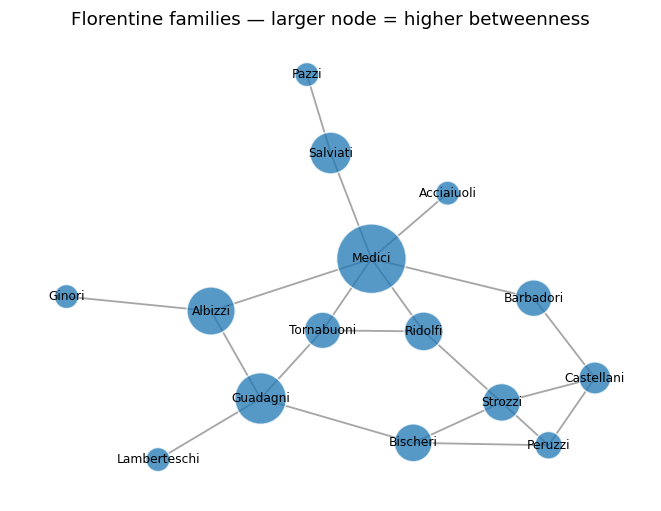

In [ ]:
pos = nx.spring_layout(F, seed=4)
size = 250 + 3500 * pd.Series(nx.betweenness_centrality(F))[list(F.nodes)].values

fig, ax = plt.subplots(figsize=(7.5, 5.5))
nx.draw_networkx_edges(F, pos, ax=ax, edge_color="0.65", width=1.2)
nx.draw_networkx_nodes(F, pos, ax=ax, node_size=size, node_color="tab:blue", alpha=0.75, edgecolors="white")
nx.draw_networkx_labels(F, pos, ax=ax, font_size=8)
ax.set_title("Florentine families — larger node = higher betweenness")
ax.axis("off")
plt.show()

**What to notice.** Three things stand out.

**1. The Medici are the biggest node by a wide margin.** Try tracing a route from Acciaiuoli or Salviati to almost any other family: it goes through the Medici. So do many routes between the Albizzi–Guadagni side and the Barbadori–Castellani side. Pull the Medici out and Acciaiuoli is cut off entirely, Salviati and Pazzi break away, and the two sides lose their shortcut. That is what a betweenness of about 0.52 looks like.

**2. Dead ends are tiny.** Ginori, Lamberteschi, Acciaiuoli, and Pazzi each have a single tie. A route can start or end at them, but never pass through them, so their betweenness is zero.

**3. Same degree, different size.** Guadagni and Strozzi both have four ties, yet Guadagni is much larger. Strozzi's neighbors are tied to one another (Peruzzi, Castellani, and Bischeri form a tight cluster), so routes can go around it. Guadagni's four neighbors have no ties among themselves, so more routes need Guadagni.

We did not sort families into "important" and "unimportant." The Medici's own list of six neighbors looks unremarkable, since Strozzi's list has four and Guadagni's has four. What makes the Medici stand out is **where those six ties lead**: to the dead ends, to the left side, and to the right side. That only shows up when we look at how all the families relate to each other.

> **Big idea.** The relationships are the data.

---
## Part 1 — What a graph is, as data

A graph has two ingredients: **nodes** (the things) and **edges** (the relationships between them). Both can carry **properties**: a node might have a name and a birth year, and an edge might have a start date and a strength.

Different fields use different words for the same pieces, so you will hear all of these:

| In this notebook | Also called |
|---|---|
| node | vertex, entity |
| edge | link, tie, relationship |

NetworkX offers a few flavors of graph. The choice encodes an assumption about your data, so it is worth making deliberately.

| Class | Edge direction | Parallel edges | Reach for it when |
|---|---|---|---|
| `Graph` | undirected | no | ties are symmetric (marriage, co-occurrence) |
| `DiGraph` | directed | no | direction matters (links, citations) |
| `MultiDiGraph` | directed | yes | two entities can be related in several ways at once (triples, property graphs) |



### 1.1 From a sentence to a graph

Start with the simplest fact we can state: **Bob knows Alice.** A triple splits a sentence into three roles:

- the **subject**: who or what it is about (Bob)
- the **predicate**: the relationship (knows)
- the **object**: the other end (Alice)

In a graph, the subject and object become **nodes**, and the predicate becomes the label on an **edge**. One triple is two nodes and one labeled edge.

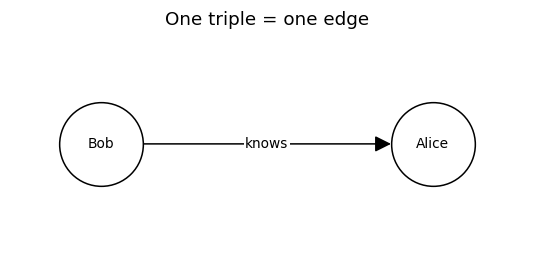

In [ ]:
def show_graph(G, pos, edge_labels, title, figsize=(6, 2.6), node_size=3000, font_size=9):
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size, node_color="white", edgecolors="black")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=font_size)
    nx.draw_networkx_edges(G, pos, ax=ax, node_size=node_size, arrowsize=22)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=9, rotate=False,
                                 bbox=dict(fc="white", ec="none", pad=1))
    ax.set_title(title); ax.margins(0.2); ax.axis("off")
    plt.show()

subject, predicate, obj = "Bob", "knows", "Alice"          # one sentence, split into its three roles
one = nx.DiGraph()
one.add_edge(subject, obj)                                  # two nodes, one edge
show_graph(one, {"Bob": (0, 0), "Alice": (2, 0)}, {("Bob", "Alice"): predicate}, "One triple = one edge")

Now add more sentences. Every new triple adds an edge, and any node that appears twice is *shared*, which is how separate facts join up into one graph. Here are eight triples in the spirit of the Module 4 examples.

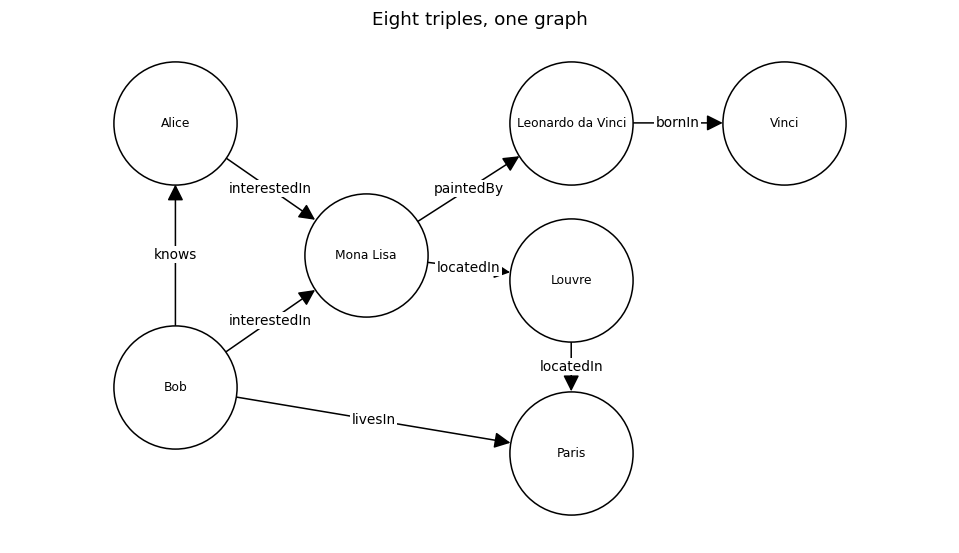

MultiDiGraph with 7 nodes and 8 edges

Everything within 2 hops of Bob (following edge direction):
{'Bob': 0, 'Mona Lisa': 1, 'Alice': 1, 'Paris': 1, 'Leonardo da Vinci': 2, 'Louvre': 2}


In [ ]:
triples = [
    ("Bob",              "interestedIn", "Mona Lisa"),
    ("Alice",            "interestedIn", "Mona Lisa"),
    ("Bob",              "knows",        "Alice"),
    ("Bob",              "livesIn",      "Paris"),
    ("Mona Lisa",        "paintedBy",    "Leonardo da Vinci"),
    ("Mona Lisa",        "locatedIn",    "Louvre"),
    ("Louvre",           "locatedIn",    "Paris"),
    ("Leonardo da Vinci","bornIn",       "Vinci"),
]

T = nx.MultiDiGraph()
for s, p, o in triples:
    T.add_edge(s, o, key=p)          # the predicate becomes the edge's identity

# draw it (a plain DiGraph copy is enough for the picture, since no pair repeats)
pos = {"Alice": (-2, 1.6), "Bob": (-2, -1.6), "Mona Lisa": (0.5, 0), "Leonardo da Vinci": (3.2, 1.6),
       "Vinci": (6, 1.6), "Louvre": (3.2, -0.3), "Paris": (3.2, -2.4)}
show_graph(nx.DiGraph(T), pos, {(s, o): p for s, p, o in triples}, "Eight triples, one graph",
           figsize=(11, 6), node_size=6500, font_size=8)

print(T)
print()
print("Everything within 2 hops of Bob (following edge direction):")
print(nx.single_source_shortest_path_length(T, "Bob", cutoff=2))

**What to notice.** Look at Mona Lisa: Bob and Alice both point to it, and it points on to Leonardo and the Louvre. Nobody told the computer that Bob and Alice share an interest. It follows from the shared node.

The last line is a *graph query*: "what can I reach from Bob in at most two steps?" The answer is a number of steps for each place: Mona Lisa, Alice, and Paris are one step away, and Leonardo da Vinci and the Louvre are two. Notice this is a question about **paths**, not about any single row. Keep that in mind for Part 2.

### 1.2 The property-graph difference: relationships can carry data

Now add one more detail: **Bob has known Alice since 2019.**

A triple has exactly three slots, and "Bob knows Alice" fits. But "since 2019" isn't about Bob or about Alice. It is about the *relationship*, and there is no slot for that. So where does the 2019 go? There are two answers.

**Answer 1: the RDF way.** RDF triples are deliberately minimal, so the workaround is to give the whole fact its own name, `_:stmt1` (think "Fact #1"), and then describe Fact #1 with several triples that all start with it. This trick is called **reification**.

RDF reification: 5 triples to say 'Bob has known Alice since 2019'
    ('_:stmt1', 'rdf:type', 'rdf:Statement')
    ('_:stmt1', 'rdf:subject', 'Bob')
    ('_:stmt1', 'rdf:predicate', 'knows')
    ('_:stmt1', 'rdf:object', 'Alice')
    ('_:stmt1', 'since', 2019)


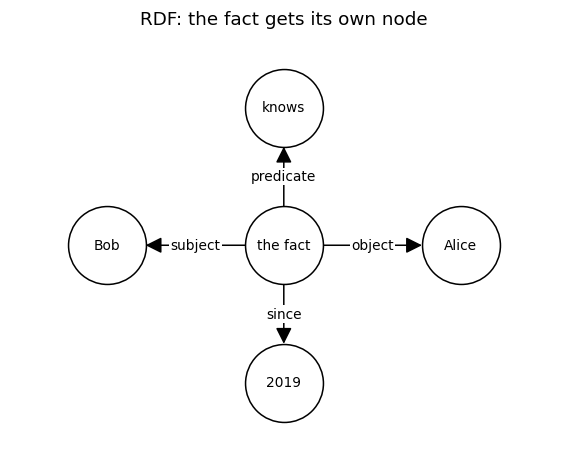

In [ ]:
reified = [
    ("_:stmt1", "rdf:type",      "rdf:Statement"),
    ("_:stmt1", "rdf:subject",   "Bob"),
    ("_:stmt1", "rdf:predicate", "knows"),
    ("_:stmt1", "rdf:object",    "Alice"),
    ("_:stmt1", "since",         2019),
]
print(f"RDF reification: {len(reified)} triples to say 'Bob has known Alice since 2019'")
for t in reified:
    print("   ", t)

# and here is the same idea as a picture (the rdf:type line is left out to keep it readable)
fact = nx.DiGraph()
for target in ["Bob", "Alice", "knows", "2019"]:
    fact.add_edge("the fact", target)
show_graph(fact,
           {"the fact": (0, 0), "Bob": (-2, 0), "Alice": (2, 0), "knows": (0, 2), "2019": (0, -2)},
           {("the fact", "Bob"): "subject", ("the fact", "Alice"): "object",
            ("the fact", "knows"): "predicate", ("the fact", "2019"): "since"},
           "RDF: the fact gets its own node", figsize=(6.4, 5), node_size=2600)

Reading the output, line by line:

| Line | What the line says |
|---|---|
| `('_:stmt1', 'rdf:type', 'rdf:Statement')` | Fact #1 is a statement. This just says what kind of thing it is. |
| `('_:stmt1', 'rdf:subject', 'Bob')` | Fact #1 is about Bob. |
| `('_:stmt1', 'rdf:predicate', 'knows')` | The relationship is "knows." |
| `('_:stmt1', 'rdf:object', 'Alice')` | The other person is Alice. |
| `('_:stmt1', 'since', 2019)` | Fact #1 has held since 2019. |

The middle three lines are just "Bob knows Alice" taken apart. The last line is the one that was impossible before, because now the fact has a name to attach `2019` to. Look at the picture: the fact became a node in the middle, with one edge out to each piece. The cost is five triples to say one thing.

**Answer 2: the property-graph way.** A **labeled property graph** lets the edge itself carry data. This is the model Neo4j uses, and it is where Part B is headed.

Property graph: one edge, properties attached
    (Bob)-[:knows {'since': 2019, 'strength': 0.8}]->(Alice)
    (Bob)-[:worksWith {'since': 2022}]->(Alice)


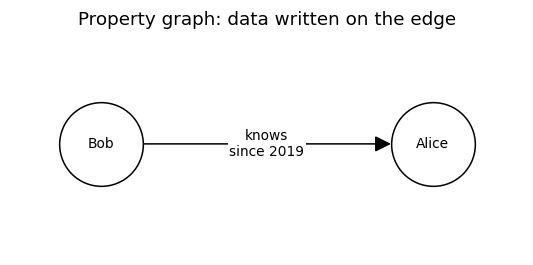

In [ ]:
P = nx.MultiDiGraph()
P.add_node("Bob",   kind="Person", born=1990)
P.add_node("Alice", kind="Person", born=1988)
P.add_edge("Bob", "Alice", key="knows",     since=2019, strength=0.8)
P.add_edge("Bob", "Alice", key="worksWith", since=2022)     # a second, parallel relationship

print("Property graph: one edge, properties attached")
for u, v, k, d in P.edges(keys=True, data=True):
    print(f"    ({u})-[:{k} {d}]->({v})")

# the same edge as a picture: the data is written on the edge
nice = nx.DiGraph()
nice.add_edge("Bob", "Alice")
show_graph(nice, {"Bob": (0, 0), "Alice": (2, 0)}, {("Bob", "Alice"): "knows\nsince 2019"},
           "Property graph: data written on the edge")

The printed lines use a notation that imitates how you would draw the graph, and it is close to how Cypher (the Neo4j query language) writes patterns in Part B:

- `(Bob)`: parentheses mean a **node**.
- `-[ ... ]->`: square brackets mean the **edge**, and the arrow shows its direction.
- `:knows`: the edge's name.
- `{...}`: the edge's own **properties**.

So the first line means: an edge from Bob to Alice, named `knows`, carrying `since: 2019` and `strength: 0.8`. All of it sits on the one edge, and no helper node is needed. (`strength` is extra data added to show that an edge can hold more than one property.)

The second line is a separate edge between the *same two people*: `worksWith`, since 2022. Two edges between the same pair is why the code uses a `MultiDiGraph`. A plain `DiGraph` would have kept only one of them.

One more thing to see: because the data sits on the edge, a question about it is easy to ask.

In [ ]:
print("Relationships that began before 2021:",
      [(u, k, v) for u, v, k, d in P.edges(keys=True, data=True) if d.get("since", 9999) < 2021])

Relationships that began before 2021: [('Bob', 'knows', 'Alice')]


The code looks at every edge, reads its `since` property, and keeps the ones below 2021. `knows` (2019) qualifies and `worksWith` (2022) does not, so the answer is a single relationship, printed as `(from, relationship, to)`. In RDF the same question takes a detour: find the fact nodes with a small `since`, then follow `subject`, `predicate`, and `object` to recover which relationship each one describes.

> **Big idea.** RDF can only label an edge, so to attach data it turns the edge into a node. A property graph lets the edge carry the data itself.

---
## Part 2 — Why graph databases exist: cost tracks what you touch

Here is a fair question. You already know how to store data in tables. So why would anyone build a whole separate kind of database just for graphs?

The answer comes down to one kind of question: **who is within a few hops of this node?** One hop is a direct connection, two hops is a friend of a friend, three hops is a friend of a friend of a friend. Questions about a network are almost always about a neighborhood like that.

So we will answer the same question three ways, on networks that keep getting bigger, and watch what happens to the time.

**First, how do we store a network in a table?** With one row per connection. The `src` column (short for *source*) is where the connection starts, and `dst` (short for *destination*) is where it ends. Here is a tiny network of five connections.

In [ ]:
mini = pd.DataFrame({"src": ["Ann", "Ann", "Ben", "Cy",  "Dee"],
                     "dst": ["Ben", "Cy",  "Dee", "Eli", "Fay"]})
mini

,src,dst
0,Ann,Ben
1,Ann,Cy
2,Ben,Dee
3,Cy,Eli
4,Dee,Fay


Read it row by row: Ann connects to Ben, Ann connects to Cy, Ben connects to Dee, and so on. In the experiment below the edge table works the same way, except every connection is stored in both directions so friendships work both ways, which is why the number of rows is twice the number of connections.

**Now, three ways to find Ann's friends.** Think of one long sheet of paper listing every friendship in a city:

| Method | How the network is stored | How it finds Ann's friends | The sheet of paper |
|---|---|---|---|
| 1. Scan-join | The edge table above | Reads **every row** and keeps the rows whose `src` is Ann | You read the whole sheet, top to bottom, every time |
| 2. Indexed join | The same table, plus an **index** on the `src` column | Looks up "Ann" in the index and jumps straight to her rows | The sheet has an alphabetical index at the back |
| 3. Traversal | Each node keeps its own **list of neighbors** | Opens Ann's list and reads it | Every person carries a card listing their friends |

The third method needs a picture. Instead of one long table, each node keeps its own short list of who it connects to. In Python that is a dictionary, with the node's name as the key and its list as the value.

In [ ]:
neighbors = {
    "Ann": ["Ben", "Cy"],
    "Ben": ["Dee"],
    "Cy":  ["Eli"],
    "Dee": ["Fay"],
    "Eli": [],
    "Fay": [],
}

# a 3-hop walk from Ann: at each hop, open the lists of the nodes we just reached
seen, frontier = {"Ann"}, ["Ann"]
for hop in range(1, 4):
    nxt = []
    for node in frontier:
        for friend in neighbors[node]:          # open this node's own list
            if friend not in seen:
                seen.add(friend); nxt.append(friend)
    print(f"hop {hop}: looked up {frontier} -> reached {nxt}")
    frontier = nxt

hop 1: looked up ['Ann'] -> reached ['Ben', 'Cy']
hop 2: looked up ['Ben', 'Cy'] -> reached ['Dee', 'Eli']
hop 3: looked up ['Dee', 'Eli'] -> reached ['Fay']


The nodes we just reached are called the **frontier**, the leading edge of the search. Each line of output is one hop: we open the lists of the frontier nodes, and the neighbors we find become the next frontier.

Notice the line `neighbors[node]`. It goes straight to Ann's list, or Ben's, or Cy's, and reads only that list. The scan-join answers "who does Ann connect to?" by checking every row of the table. The traversal never looks at Fay's entry while working on Ann's. That is the whole idea, and now we can measure it.

**The experiment.** We build random networks of 10,000, 100,000, and 400,000 nodes, with about ten ties per node in each. We pick a start node whose 3-hop neighborhood has roughly the same size (about a thousand nodes) every time, so the *question* stays the same size and only the *dataset* grows. Then we time all three methods. We are watching how the cost grows, not crowning a winner.

In [ ]:
def hops_scan_join(edges, start, hops):
    seen, frontier = {start}, pd.DataFrame({"node": [start]})
    for _ in range(hops):
        nxt = (frontier.merge(edges, left_on="node", right_on="src")[["dst"]]
                       .drop_duplicates().rename(columns={"dst": "node"}))
        frontier = nxt[~nxt["node"].isin(seen)]
        seen |= set(frontier["node"])
    return seen

def hops_indexed_join(edges_idx, start, hops):
    seen, frontier = {start}, np.array([start])
    for _ in range(hops):
        dst = np.unique(edges_idx.loc[frontier, "dst"].to_numpy())
        frontier = np.array([d for d in dst if d not in seen])
        seen |= set(frontier.tolist())
        if len(frontier) == 0:
            break
    return seen

def hops_traversal(G, start, hops):
    seen, frontier = {start}, [start]
    for _ in range(hops):
        nxt = []
        for u in frontier:
            for v in G.adj[u]:
                if v not in seen:
                    seen.add(v); nxt.append(v)
        frontier = nxt
    return seen

def best_of(fn, *args, reps=3):
    times = []
    for _ in range(reps):
        t0 = time.perf_counter(); out = fn(*args); times.append(time.perf_counter() - t0)
    return min(times) * 1000, out          # milliseconds

def pick_start(G, target=1000, tries=30):
    # choose a start node whose 3-hop neighborhood is close to `target` nodes, so that
    # only the SIZE OF THE DATASET changes from one network to the next, not the question
    cands = list(range(tries))
    return min(cands, key=lambda s: abs(len(hops_traversal(G, s, 3)) - target))

rows = []
for size_n in [10_000, 100_000, 400_000]:
    G = nx.gnm_random_graph(size_n, 5 * size_n, seed=0)   # ~10 ties per node, however large the network
    e = np.array(G.edges())
    edges = pd.DataFrame({"src": np.r_[e[:, 0], e[:, 1]], "dst": np.r_[e[:, 1], e[:, 0]]})
    edges_idx = edges.set_index("src").sort_index()
    start = pick_start(G)

    t_scan, a = best_of(hops_scan_join, edges, start, 3)
    t_idx,  b = best_of(hops_indexed_join, edges_idx, start, 3)
    t_trav, c = best_of(hops_traversal, G, start, 3)
    assert a == b == c                       # all three must agree on the answer
    rows.append({"nodes": size_n, "edge rows": len(edges), "nodes reached": len(c),
                 "scan-join ms": t_scan, "indexed-join ms": t_idx, "traversal ms": t_trav})

timing = pd.DataFrame(rows).set_index("nodes")
display(timing.round(2))

,edge rows,nodes reached,scan-join ms,indexed-join ms,traversal ms
nodes,,,,,
10000,100000,906,7.71,1.04,0.09
100000,1000000,1005,68.73,1.07,0.10
400000,4000000,1013,239.08,1.07,0.10


**What to look for.** Read down each timing column, not across. The question is the same size every time (about a thousand nodes reached), so the only thing changing between rows is the size of the data. Times are in milliseconds, so 1,000 ms is one second.

- **scan-join** grows in step with the data: about ten times more rows took about ten times longer. It searches every row on every hop.
- **indexed-join** stays roughly flat. It jumps straight to the rows it needs, so the table's size barely matters.
- **traversal** stays roughly flat, and lowest. It follows each node's neighbor list directly, so it only touches the nodes near the start.

The exact milliseconds depend on the machine, so yours will differ a little. The pattern is what matters. Here is the same thing as a picture, on a log scale so all three lines fit (each gridline is ten times bigger than the one below it).

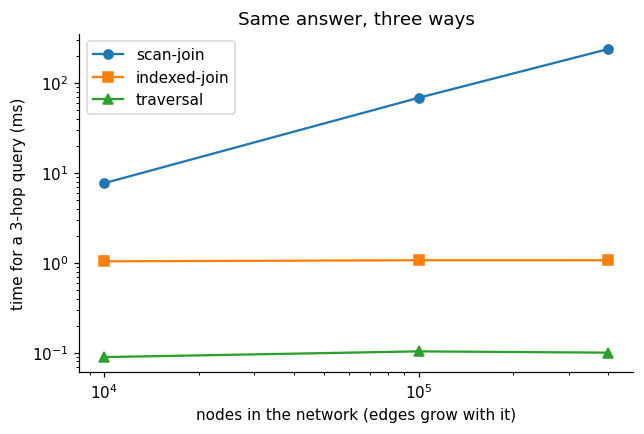

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for col, style in [("scan-join ms", "o-"), ("indexed-join ms", "s-"), ("traversal ms", "^-")]:
    ax.plot(timing.index, timing[col], style, label=col.replace(" ms", ""))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("nodes in the network (edges grow with it)")
ax.set_ylabel("time for a 3-hop query (ms)")
ax.set_title("Same answer, three ways")
ax.legend()
plt.show()

Let's remember to read benchmarks critically:

- The **scan-join** cost climbs with the size of the table, even though the answer (a neighborhood of about the same size each time) does not grow. It is paying for everything it does *not* need.
- The **indexed join** closes most of that gap. A real relational database with an index would look like this line, not the scan-join line. Dramatic "graphs are hundreds of times faster than joins" claims are sometimes measured against something like the first line.
- **Traversal** cost follows the size of the neighborhood you actually visit, not the size of the dataset. So does the indexed join. The remaining gap between those two lines is a constant factor that reflects how this particular Python code is written, so do not read it as a database benchmark.

So the lesson is not that graph databases are faster at everything. The lesson is about where the speed comes from. A graph database stores each node with direct access to its neighbors, so a question about one neighborhood stays fast however large the network grows. It also provides a query language for asking multi-hop questions without writing the loops yourself.

> **Big idea.** Ask whether a method's cost follows the size of the *data* or the size of the *neighborhood*.

---
## Part 3 — Geometry: a node's neighborhood is a point in space

From here on we use one network throughout: **Zachary's Karate Club** (Zachary, 1977). Thirty-four members of a university karate club, with an edge wherever two members interacted outside of class. (NetworkX's copy also records how often they interacted. We ignore those counts so that every edge counts the same.)

While the study was running, a dispute over lesson fees split the club in two: one side followed the part-time instructor ("Mr. Hi"), and the other followed the club's administrator ("John A."; NetworkX labels that side "Officer"). Because we know how the club actually divided, we can check what the geometry finds, but only *after* we compute it.



### 3.1 The adjacency matrix: every node is a row, and every row is a point

The **adjacency matrix** $A$ has $A_{ij}=1$ if nodes $i$ and $j$ are connected and $0$ otherwise. Read one row of $A$ and you have a list of numbers with one entry per node: *which nodes am I connected to?* Here is a tiny four-node example.

<img src="https://raw.githubusercontent.com/gitmystuff/Linkables/refs/heads/main/adjacency_matrix_tiny_example.png" alt="a four-node graph and its adjacency matrix" />

Read the row labeled A: `0 1 1 0`. A is not connected to itself (0), is connected to B (1), is connected to C (1), and is not connected to D (0). Every row is one node's connections written as numbers. The Karate Club works the same way, with 34 nodes.

adjacency matrix shape: (34, 34) | symmetric: True
row 0 (member 0's position in 34-dimensional space):
[0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0]


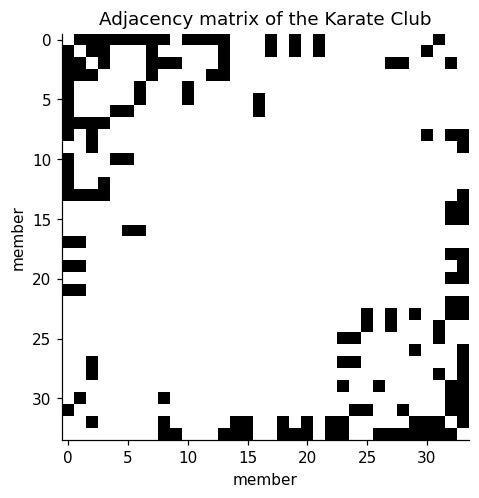

In [ ]:
K = nx.karate_club_graph()
for _, _, d in K.edges(data=True):          # NetworkX's copy also stores interaction counts as edge weights;
    d.pop("weight", None)                   # drop them so that A is a plain 0/1 matrix
nodes = list(K.nodes)                       # 0 ... 33
n = len(nodes)
A = nx.to_numpy_array(K, nodelist=nodes)    # 34 x 34, symmetric, 0/1
truth = np.array([1 if K.nodes[i]["club"] == "Mr. Hi" else 0 for i in nodes])   # held back for checking only

print("adjacency matrix shape:", A.shape, "| symmetric:", np.allclose(A, A.T))
print("row 0 (member 0's position in 34-dimensional space):")
print(A[0].astype(int))

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.imshow(A, cmap="Greys")
ax.set_title("Adjacency matrix of the Karate Club")
ax.set_xlabel("member"); ax.set_ylabel("member")
plt.show()

**Reading the output.**

- `shape: (34, 34)`: one row and one column for each of the 34 members.
- `symmetric: True`: if member 0 is connected to member 1, then member 1 is connected to member 0. The grid mirrors across its diagonal.
- Row 0 is member 0's 34 numbers, one for each member. A 1 at position 3 means member 0 is connected to member 3. This row has sixteen 1s, so member 0 has sixteen connections. The label says "34-dimensional space" because those 34 numbers act as 34 coordinates. That is our frame again: **a row is a point in space.**

**Reading the picture.** Black squares are 1 (connected) and white squares are 0. The white diagonal shows that nobody is connected to themselves, and the picture mirrors across that diagonal. The heavy stripes are members 0 and 33, the club's two hubs.

Now look at the corners. The top-left corner holds connections among members 0 to 13. The bottom-right holds connections among members 23 to 33. The other two corners hold connections *between* those two ranges, and they are mostly empty. About 31% of possible pairs among members 0 to 13 are connected, about 38% among members 23 to 33, but only about 6.5% between the two ranges (across the whole club, about 14%). So members mostly connect within their own range, which hints at two groups.

**But are the corners real?** The member numbers are only labels: the order in which members happened to be listed. Let's test that. If we shuffle the order, the network stays exactly the same, and only the picture changes.

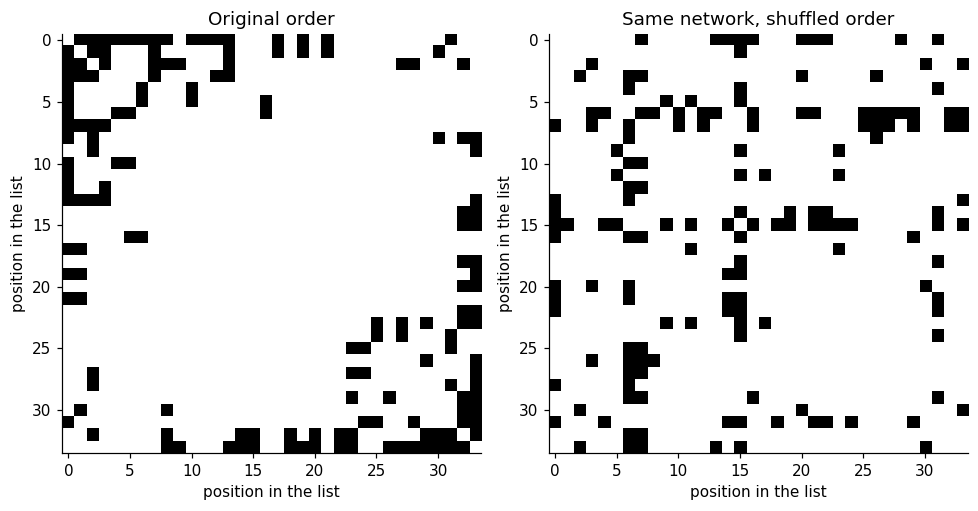

In [ ]:
rng = np.random.default_rng(0)
shuffle = rng.permutation(n)                      # a random new order for the members
A_shuffled = A[np.ix_(shuffle, shuffle)]          # same connections, rows and columns reordered

fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
axes[0].imshow(A, cmap="Greys");           axes[0].set_title("Original order")
axes[1].imshow(A_shuffled, cmap="Greys");  axes[1].set_title("Same network, shuffled order")
for a in axes: a.set_xlabel("position in the list"); a.set_ylabel("position in the list")
plt.tight_layout(); plt.show()

The right-hand picture looks scattered, with no clear corners, even though every connection is still there. So the corners in the original picture came from the order in which the members happened to be listed (which roughly followed the two sides), and the network itself doesn't carry that order. What matters is who is connected to whom.

This sets up Part 5, where we find an ordering *from the network itself*, so the groups appear no matter how the members were first numbered.

### 3.2 Shortest-path distance is a genuine metric

Define $d(i,j)$ as the number of edges on the shortest path from $i$ to $j$. Then a graph becomes a **metric space**: it has a real notion of distance. Here is the same four-node graph again, this time with the number of steps between each pair.

<img src="https://raw.githubusercontent.com/gitmystuff/Linkables/refs/heads/main/shortest_path_distance_matrix_tiny_example.png" alt="a four-node graph and its shortest-path distance grid" />

The entry for A and D is 2, because the shortest route is A to C to D, which takes two steps. A **metric** is any way of measuring distance that follows three common-sense rules, and the grid shows all three:

- **Rule 1, a node is zero away from itself and from nobody else.** The diagonal is all zeros, and no other cell holds a zero.
- **Rule 2, the distance is the same in both directions.** A to D is 2, and D to A is 2. The grid mirrors across its diagonal.
- **Rule 3, a detour is never shorter than the direct route.** Going from A to D via C costs 1 + 1 = 2, and going via B costs 1 + 2 = 3. No stop along the way beats the shortest route. This is called the *triangle inequality*: one side of a triangle is never longer than the other two sides added together.

Let's check all three rules on the Karate Club, rather than assume them.

In [ ]:
sp = dict(nx.all_pairs_shortest_path_length(K))
D = np.array([[sp[i][j] for j in nodes] for i in nodes], dtype=float)

identity  = np.all((D == 0) == np.eye(n, dtype=bool))
symmetry  = np.allclose(D, D.T)
triangle  = all(np.all(D <= D[:, [b]] + D[[b], :]) for b in range(n))    # d(a,c) <= d(a,b) + d(b,c)

print("d(i,j)=0 only when i=j :", identity)
print("d(i,j) = d(j,i)        :", symmetry)
print("triangle inequality    :", triangle)
print()
print(f"diameter (longest shortest path): {int(D.max())}   radius: {nx.radius(K)}   center nodes: {nx.center(K)}")

d(i,j)=0 only when i=j : True
d(i,j) = d(j,i)        : True
triangle inequality    : True

diameter (longest shortest path): 5   radius: 3   center nodes: [0, 1, 2, 3, 8, 13, 19, 31]


**Reading the output.** The first line of code collects the number of steps between every pair of members into a 34 by 34 grid `D`, the same shape as the adjacency matrix but holding distances instead of 0s and 1s. (Row 0 begins `0, 1, 1, 1, 1, 1, 1, 1, 1, 2`, so member 0 is one step from members 1 through 8 and two steps from member 9.) The next three lines test the three rules, one each.

The three `True` lines mean all three rules hold. That is expected: shortest-path distance on an ordinary graph must satisfy them, because a detour that were shorter would simply be the shortest path. The check is reassuring, and it confirms the code built `D` correctly.

The last line reports three summary numbers, all read from the grid:

- **Diameter: 5.** The largest number in the grid. The two members farthest apart are 5 steps from each other. In this network every such pair includes member 16, who is tied to only two other members and sits at the edge of the club.
- **Radius: 3.** For each member, find the farthest member from them. The radius is the smallest of those numbers: the best-placed member can reach everyone in 3 steps or fewer.
- **Center nodes: [0, 1, 2, 3, 8, 13, 19, 31].** The members who achieve that radius. Member 33, one of the two hubs, is not on the list, because there is someone 4 steps from him. Having many connections and sitting in the middle of the network are different things.

A town is a good comparison: the two residents who live farthest apart are 5 steps from each other, while someone in the middle of town can reach everyone in 3.

### 3.3 Can a graph be drawn on a flat page?

Here is a question that sounds strange. Suppose we tried to *draw* the 34 members on a sheet of paper: each member is a point, and the ruler distance between two points should equal the number of steps between those two members. Could we do it?

Sometimes, yes. Four members in a row, A–B–C–D, can sit on a line one inch apart, and every ruler distance matches the step count. Sometimes, no. Take a hub X connected to three separate leaves P, Q, and R.

- X is one step from each leaf.
- The leaves are two steps from each other, and the route goes through X.

So X has to sit exactly halfway between P and Q, and also halfway between P and R, and also halfway between Q and R. Those are three different spots, and X can only be in one.

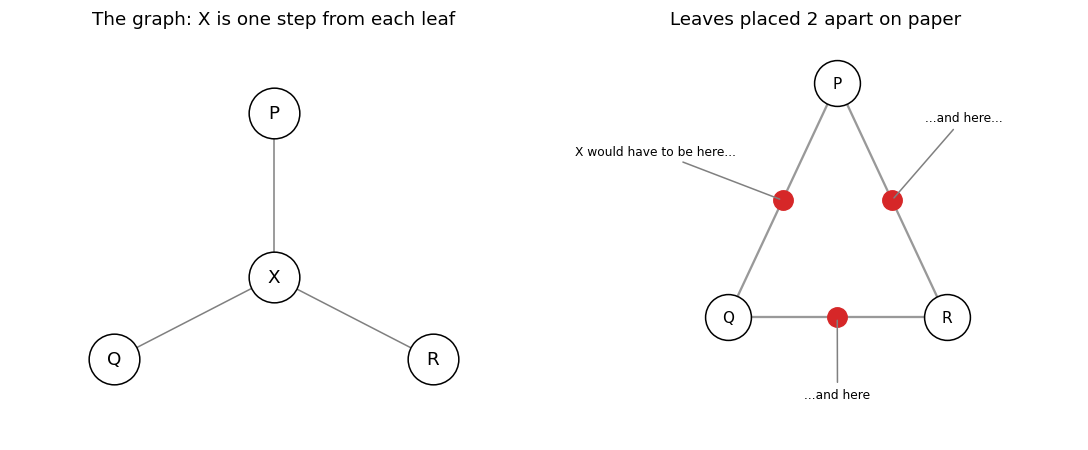

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# left: the graph
star = nx.star_graph(3)                       # node 0 is the hub; 1, 2, 3 are the leaves
spos = {0: (0, 0), 1: (0, 1), 2: (-0.87, -0.5), 3: (0.87, -0.5)}
nx.draw_networkx_edges(star, spos, ax=axes[0], edge_color="0.5")
nx.draw_networkx_nodes(star, spos, ax=axes[0], node_size=1100, node_color="white", edgecolors="black")
nx.draw_networkx_labels(star, spos, labels={0: "X", 1: "P", 2: "Q", 3: "R"}, ax=axes[0])
axes[0].set_title("The graph: X is one step from each leaf"); axes[0].margins(0.25); axes[0].axis("off")

# right: place the three leaves 2 apart on paper, and mark where X would have to be
P_, Q_, R_ = np.array([0, 1.73]), np.array([-1, 0]), np.array([1, 0])
for a, b in [(P_, Q_), (P_, R_), (Q_, R_)]:
    axes[1].plot(*zip(a, b), color="0.6", lw=1.5, zorder=1)
for pt, lab in [(P_, "P"), (Q_, "Q"), (R_, "R")]:
    axes[1].scatter(*pt, s=900, color="white", edgecolors="black", zorder=3)
    axes[1].annotate(lab, pt, ha="center", va="center", zorder=4)
for mid in [(P_ + Q_) / 2, (P_ + R_) / 2, (Q_ + R_) / 2]:
    axes[1].scatter(*mid, s=160, color="tab:red", zorder=2)
axes[1].annotate("X would have to be here...", (P_ + Q_) / 2, xytext=(-2.4, 1.2), fontsize=8,
                 arrowprops=dict(arrowstyle="-", color="0.5"))
axes[1].annotate("...and here...", (P_ + R_) / 2, xytext=(0.8, 1.45), fontsize=8,
                 arrowprops=dict(arrowstyle="-", color="0.5"))
axes[1].annotate("...and here", (Q_ + R_) / 2, xytext=(-0.3, -0.6), fontsize=8,
                 arrowprops=dict(arrowstyle="-", color="0.5"))
axes[1].set_xlim(-2.6, 2.2); axes[1].set_ylim(-0.9, 2.1)
axes[1].set_title("Leaves placed 2 apart on paper"); axes[1].axis("off")
plt.tight_layout(); plt.show()

The three red points are the three places X would have to be. No drawing on paper, or in a room, or in any number of dimensions, gets all the distances right. Networks with branching structure like this **cannot be drawn flat without distorting some distances.** ("Flat" here means ordinary straight-line geometry, measured with a ruler.)

A standard tool called **multidimensional scaling (MDS)** tries to do the drawing for us. Alongside its picture it reports a list of numbers called **eigenvalues**, one for each direction. Positive ones measure how spread out the members are along that direction. **Negative ones are a warning: they measure distances that no flat drawing can match.** Let's see what MDS says about the Karate Club.

largest eigenvalues : [66.  14.7  8.7  7.1]
smallest eigenvalues: [ -2.4  -3.4  -4.1 -10.8]
negative eigenvalues: 11 of 34
correlation between 2-D distances and graph distances: 0.864


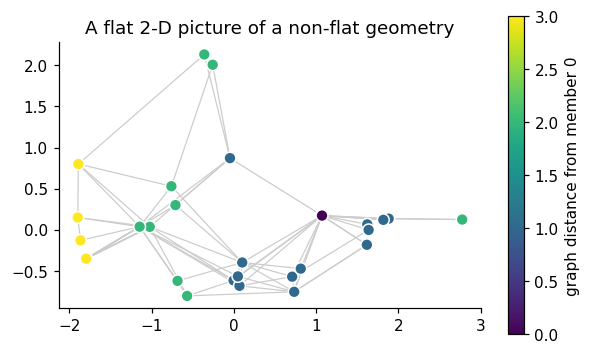

In [ ]:
J = np.eye(n) - np.ones((n, n)) / n            # centering matrix
B = -0.5 * J @ (D ** 2) @ J                    # double-centered squared distances
w, V = np.linalg.eigh(B)
idx = np.argsort(w)[::-1]
w, V = w[idx], V[:, idx]

print("largest eigenvalues :", np.round(w[:4], 1))
print("smallest eigenvalues:", np.round(w[-4:], 1))
print("negative eigenvalues:", int((w < -1e-9).sum()), "of", n)

# best flat 2-D picture, and how badly it distorts the true distances
from scipy.spatial.distance import pdist
xy = V[:, :2] * np.sqrt(w[:2])
flat = pdist(xy)
true = D[np.triu_indices(n, k=1)]
print("correlation between 2-D distances and graph distances:", round(np.corrcoef(flat, true)[0, 1], 3))

fig, ax = plt.subplots(figsize=(6.2, 5))
for u, v in K.edges:
    ax.plot(*zip(xy[u], xy[v]), color="0.8", lw=0.8, zorder=1)
sc = ax.scatter(xy[:, 0], xy[:, 1], c=D[0], cmap="viridis", s=60, zorder=2, edgecolors="white")
plt.colorbar(sc, label="graph distance from member 0", shrink=0.75)
ax.set_title("A flat 2-D picture of a non-flat geometry")
ax.set_aspect("equal")
plt.show()

**Reading the output.**

- **The picture.** Each point is a member, and the color shows how many steps that member is from member 0. Member 0 is the dark purple point, its direct connections are dark blue, then green, then yellow for the farthest. The layout roughly follows those distances: the yellow points sit at the far left.
- **The eigenvalues.** The 34 numbers are not one per member. Each one describes a *direction* through the cloud of members, and its size says how spread out the cloud is along that direction. Picture a cigar-shaped cloud: long in one direction, narrower in a second, thin in a third. The two biggest numbers (66 and 14.7) are the two directions the picture uses as its x-axis and y-axis. The spread is measured from the middle of the cloud, so member 0 has no special role.
- **The correlation, 0.864.** How closely the 2-D distances track the real step counts (1.0 would be perfect). The picture is good, not exact.
- **The warning.** Eleven of the 34 eigenvalues are negative, so no flat drawing can match all these distances, exactly like the hub-and-leaves example. Every 2-D drawing of a network is a compromise, and that foreshadows a choice in a later module: how many dimensions to give a node embedding, and how much distortion to accept.

> **Big idea.** A graph is more than a table of connections: its nodes have positions and distances. But that geometry is not always flat, so any picture of it is a compromise.

---
## Part 4 — PageRank: importance, found by wandering

In Part 0 we measured importance three ways: degree, closeness, and betweenness. **PageRank** is a fourth, and it is the idea behind Google Search. The web is a network of pages, and a link from one page to another acts like a vote. PageRank asks: *if someone wandered through the network at random, where would they spend their time?*

**The random walk.** Imagine a wanderer starting at any member. At each step, they look at the connections of the member they're standing on, pick one at random, and walk along it. After a very long time, some members will have been visited far more often than others. The share of time spent at each member is its **PageRank score**. Members who are easy to reach from many places, especially from members that are themselves visited a lot, collect more time.

**A small twist: teleporting.** On some networks a wanderer can get trapped. On a directed network (web pages, for example), a page might have no links out, or a few pages might link only to each other, and the walker would circle forever. To prevent this, the standard recipe adds a rule: some of the time, instead of following a connection, the wanderer jumps to a random member anywhere. We use the usual setting, $\alpha = 0.85$: 85% of steps follow a connection and 15% jump.

Let's actually do it. We release a wanderer on the Karate Club, let them take 200,000 steps, and count the visits.

In [ ]:
rng = np.random.default_rng(0)
neighbors_K = [list(K[i]) for i in nodes]        # each member's list of neighbors
steps = 200_000
coin  = rng.random(steps)                        # decides: follow a connection, or jump?
jump  = rng.integers(0, n, steps)                # where to jump, if we jump
pick  = rng.random(steps)                        # which neighbor to walk to, if we walk

visits = np.zeros(n)
here = 0                                         # start at member 0
for s in range(steps):
    if coin[s] < 0.85:                           # 85%: follow a random connection
        nb = neighbors_K[here]
        here = nb[int(pick[s] * len(nb))]
    else:                                        # 15%: teleport to a random member
        here = jump[s]
    visits[here] += 1

share = visits / steps                           # the share of time spent at each member

pr = nx.pagerank(K, alpha=0.85, tol=1e-12)       # NetworkX's PageRank, for comparison
pr = np.array([pr[i] for i in nodes])

top = np.argsort(-pr)[:5]
display(pd.DataFrame({"share of time (simulation)": share[top].round(4),
                      "PageRank (NetworkX)": pr[top].round(4)}, index=pd.Index(top, name="member")))
print("largest gap over all 34 members:", round(np.abs(share - pr).max(), 4))

,share of time (simulation),PageRank (NetworkX)
member,,
33,0.1010,0.1009
0,0.0960,0.0970
32,0.0721,0.0717
2,0.0571,0.0571
1,0.0518,0.0529


largest gap over all 34 members: 0.0011


**Reading the output.** The table shows the five members who got the most wandering time. They are members 33, 0, and 32 at the top, which are the two hubs and the next most connected member. The two columns agree: the share of time our wanderer actually spent at each member, and the number NetworkX's `pagerank` reports. The largest gap over all 34 members is about a tenth of one percent. So **PageRank really is just "the share of time a wanderer spends at each node."**

**Getting the answer without simulating.** We don't need 200,000 steps. Keep a list of 34 numbers, $x$: the chance the wanderer is currently at each member. Start with every member equally likely. One step of the walk shifts those chances, since members pass on the probability they hold and receive what arrives from their neighbors. That one step is a single matrix multiplication:

$$x \;\rightarrow\; G\,x, \qquad\text{where}\qquad G = \alpha\, M^\top + \frac{1-\alpha}{n}\,\mathbf{1}\mathbf{1}^\top$$

In words: $G$ is a 34 × 34 grid of numbers that combines the two rules. The first term is "follow a connection" (each row of $M$ says how a member splits its probability among its neighbors), and the second is "teleport" (everyone gets the same small share). Multiply again and again, and after enough steps the numbers stop changing, so one more step leaves the chances exactly as they were: $G\,x = x$.

In [ ]:
alpha = 0.85
M_ = A / A.sum(axis=1, keepdims=True)                   # row i splits member i's probability among its neighbors
Gm = alpha * M_.T + (1 - alpha) / n * np.ones((n, n))   # follow a connection (85%) or teleport (15%)

x = np.ones(n) / n                                      # start: every member equally likely
for step in range(1, 41):
    x = Gm @ x                                          # one step of the walk, for everyone at once
    if step in (1, 5, 10, 40):
        print(f"after {step:>2} steps, member 33 has {x[33]:.4f} and member 0 has {x[0]:.4f}")

# the exact answer, from a full eigenvector calculation
vals, vecs = np.linalg.eig(Gm)
j = np.argmax(vals.real)
pr_eig = vecs[:, j].real; pr_eig /= pr_eig.sum()

print()
print("dominant eigenvalue:", round(vals[j].real, 6))
print("largest gap, repeated multiplication vs exact answer:", f"{np.abs(x - pr_eig).max():.1e}")
print("largest gap, NetworkX pagerank vs exact answer:      ", f"{np.abs(pr - pr_eig).max():.1e}")

after  1 steps, member 33 has 0.1486 and member 0 has 0.1343
after  5 steps, member 33 has 0.1069 and member 0 has 0.1004
after 10 steps, member 33 has 0.1003 and member 0 has 0.0968
after 40 steps, member 33 has 0.1009 and member 0 has 0.0970

dominant eigenvalue: 1.0
largest gap, repeated multiplication vs exact answer: 1.1e-08
largest gap, NetworkX pagerank vs exact answer:       1.0e-11


**Reading the output.** The first lines show the numbers settling: they move a lot in the first few steps and hardly at all by step 40. The last lines compare three ways of getting the answer (repeating the multiplication, solving exactly, and calling NetworkX), and they agree to many decimal places. A number like `1e-08` is 0.00000001.

**The link to eigenvectors.** Recall from an earlier module that an eigenvector is a direction a matrix only stretches, never turns, and its eigenvalue says by how much. The equation $Gx = x$ has the same form, with a stretch factor of exactly 1, which means no change at all. So **the PageRank scores are an eigenvector of $G$**, the one belonging to the largest eigenvalue, and the printed "dominant eigenvalue: 1.0" is that stretch factor. The routine of "multiply, multiply again, repeat until nothing changes" is called **power iteration**. It has the same guess-refine-repeat rhythm as the EM algorithm from Module 1.

**One more thing to notice.** How does PageRank compare with simply counting connections? On an *undirected* network, the answer is instructive: the long-run share of time of a plain random walk is exactly proportional to degree, and teleporting bends that only slightly.

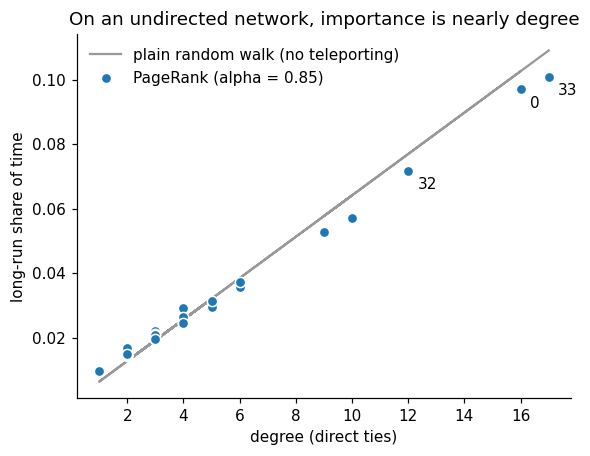

correlation(degree, PageRank): 0.9979


In [ ]:
deg = A.sum(axis=1)
pure_walk = deg / deg.sum()                            # a plain random walk (no teleporting): share of time is proportional to degree

fig, ax = plt.subplots(figsize=(5.8, 4.3))
ax.plot(deg, pure_walk, "-", color="0.6", label="plain random walk (no teleporting)")
ax.scatter(deg, pr, s=45, color="tab:blue", edgecolors="white", zorder=3, label="PageRank (alpha = 0.85)")
for i in np.argsort(-pr)[:3]:
    ax.annotate(str(i), (deg[i], pr[i]), textcoords="offset points", xytext=(6, -12))
ax.set_xlabel("degree (direct ties)")
ax.set_ylabel("long-run share of time")
ax.set_title("On an undirected network, importance is nearly degree")
ax.legend(frameon=False)
plt.show()

print("correlation(degree, PageRank):", round(np.corrcoef(deg, pr)[0, 1], 4))

The gray line is what the walk would give with no teleporting: exactly degree, rescaled. PageRank sits close to it, nudged slightly toward the middle by the teleporting. The practical lesson: **on an undirected graph, a PageRank result is mostly degree in disguise.** PageRank becomes a genuinely different measure on *directed* networks (web links, citations, follows), where the links pointing in differ from the links pointing out, and a link from an important node carries more weight than one from an obscure node.

> **Big idea.** PageRank is the share of time a wanderer spends at each node, and mathematically it is the dominant eigenvector of a matrix.

---
## Part 5 — The Laplacian: finding the two sides

In Part 4 we asked *how important is each member?* Now we ask a different question: **which members belong together?**

Here is the trick, and it is worth going slowly.

**A roughness score.**

1. Give every member a number, any number you like.
2. Go through the friendships one at a time. For each pair of friends, find how different their two numbers are (and square it, so bigger differences count for extra).
3. Add all of those up.

That total is the **roughness score**. If friends tend to have similar numbers, the total is small, and the numbering is *smooth*. If friends have very different numbers, the total is big, and the numbering is *rough*. In symbols, if member $i$ gets the number $x_i$:

$$\text{roughness} = \sum_{(i,j)\text{ connected}} (x_i - x_j)^2$$

Try it on the Karate Club with three different ways of handing out numbers. In the second, we give the instructor's side a 1 and the administrator's side a 0. (We are using the real split here only to show what the score measures.) In the third, we hand out the same 1s and 0s at random.

In [ ]:
L = np.diag(A.sum(axis=1)) - A                   # the Laplacian (explained below)

def roughness(x):
    return sum((x[i] - x[j]) ** 2 for i, j in K.edges)     # add up (difference)^2 over every friendship

same     = np.ones(n)                                       # everyone gets the same number
by_side  = truth.astype(float)                              # 1 for the instructor's side, 0 for the administrator's side
shuffled = np.random.default_rng(0).permutation(by_side)    # the same 1s and 0s, handed out at random

for name, x in [("everyone gets the same number", same),
                ("numbers follow the real split", by_side),
                ("same numbers, handed out at random", shuffled)]:
    print(f"{name:<36} roughness = {roughness(x):>5.1f}     shortcut x'Lx = {x @ L @ x:>5.1f}")

everyone gets the same number        roughness =   0.0     shortcut x'Lx =   0.0
numbers follow the real split        roughness =  11.0     shortcut x'Lx =  11.0
same numbers, handed out at random   roughness =  40.0     shortcut x'Lx =  40.0


**Reading the output.** Everyone the same scores 0, because no two friends differ. Numbers that follow the real split score only 11: most friends are on the same side and have the same number, so only the 11 friendships that *cross* between the sides disagree. The same numbers handed out at random score 40. **A numbering that follows the groups is far smoother than one that ignores them.** That is why smooth numberings reveal groups.

**The Laplacian.** The second column shows a shortcut. The **graph Laplacian** is a 34 × 34 grid of numbers built from the network,

$$L = D - A,$$

where $A$ is the adjacency matrix from Part 3 and $D$ is a grid with each member's number of connections down the diagonal and zeros everywhere else. For any numbering $x$, the matrix calculation $x^\top L\, x$ gives exactly the roughness total, and the two columns in the output agree.

**Why this finds groups.** Some numberings are special: the **eigenvectors** of $L$. For an eigenvector scaled to a standard size, its eigenvalue is exactly its roughness score. So the eigenvectors with the *smallest* eigenvalues are the *smoothest* ways to number the members. The very smoothest gives everyone the same number (roughness 0), which tells us nothing. The next smoothest is the useful one. It has to change somewhere, and the cheapest place to change is across the few connections *between* groups, so members inside a tightly connected group get similar numbers, and the numbers shift where the groups meet.

That numbering is called the **Fiedler vector** (after the mathematician Miroslav Fiedler), and each member's number in it is that member's **Fiedler coordinate**. Compare this with PCA from Module 2. Both methods use eigenvectors, but they keep opposite ends of the list.

| | PCA | Spectral embedding (this section) |
|---|---|---|
| Starts from | how the features vary together (covariance) | how the members are connected (the Laplacian) |
| Keeps | eigenvectors with the **largest** eigenvalues | eigenvectors with the **smallest** eigenvalues |
| What those directions capture | where the data is most spread out | numbers that change the least across connections |

Let's compute it, without looking at the club labels.

In [ ]:
evals_L, evecs_L = np.linalg.eigh(L)
print("smallest Laplacian eigenvalues:", np.round(evals_L[:4], 3) + 0.0)     # + 0.0 just tidies a printed "-0."

fied = evecs_L[:, 1].copy()                    # the Fiedler coordinate: one number per member
if fied[0] < 0:                                # the sign of an eigenvector is arbitrary; orient so member 0 is positive
    fied = -fied

print("Fiedler coordinates of members 0-5:", np.round(fied[:6], 3))

smallest Laplacian eigenvalues: [0.    0.469 0.909 1.125]
Fiedler coordinates of members 0-5: [ 0.112  0.041 -0.023  0.055  0.285  0.324]


**Reading the output.** The smallest eigenvalue is 0 (its numbering gives everyone the same number), and the next is about 0.47, the Fiedler vector's roughness. The second line shows the Fiedler coordinates of the first six members: one number each, some negative and some positive. Which side counts as negative is arbitrary, so we flipped the signs to put member 0 on the positive side.

Now let's use those numbers. Here is the network's adjacency matrix in the original order (left), and re-listed from the lowest Fiedler coordinate to the highest (right).

members from lowest to highest Fiedler coordinate: [26, 29, 14, 15, 20, 18, 22, 25, 23, 24, 32, 27, 33, 31, 28, 9, 30, 8, 2, 19, 13, 1, 7, 3, 17, 21, 12, 0, 11, 4, 10, 6, 5, 16]


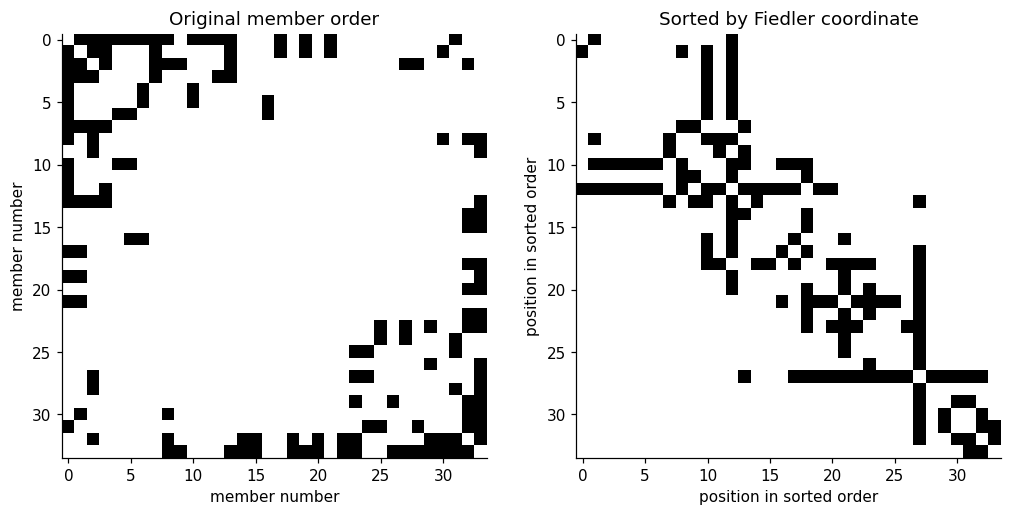

In [ ]:
order = np.argsort(fied)
print("members from lowest to highest Fiedler coordinate:", order.tolist())

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
axes[0].imshow(A, cmap="Greys");                             axes[0].set_title("Original member order")
axes[1].imshow(A[np.ix_(order, order)], cmap="Greys");       axes[1].set_title("Sorted by Fiedler coordinate")
axes[0].set_xlabel("member number");            axes[0].set_ylabel("member number")
axes[1].set_xlabel("position in sorted order"); axes[1].set_ylabel("position in sorted order")
plt.tight_layout(); plt.show()

Both pictures show the same network, with the same 78 connections. Nothing changed except the order in which the members are listed. In the right picture, the numbers along the axes are **positions in the sorted list**, not member numbers. Position 0 is the member with the lowest coordinate, which is member 26. Now compare with the shuffled picture from Part 3: there, reordering hid the structure, and here it reveals it.

**What to notice.**

1. **The black squares moved toward the diagonal.** This is because connected members get similar Fiedler coordinates (that is what smooth means). After sorting, connected members sit close together in the list, and a connection between two nearby positions is a square near the diagonal.
2. **Two long bars cross the picture,** at positions 12 and 27. Position 12 is member 33 (the administrator's hub) and position 27 is member 0 (the instructor's hub). A member with many connections has a long bar.
3. **Two groups sit along the diagonal.** The first 17 positions are all on the administrator's side, and the last 17 are all on the instructor's side. The top-right and bottom-left corners are nearly empty, which means few connections cross between the groups.
4. **The few squares far from the diagonal are the crossing connections.** For example, the lone square near row 13, column 27 is member 31 connected to member 0, someone from one side tied to the hub on the other.

We computed one number per member, from the connections alone, and the groups appeared. Now let's check the result against the real split, and see how close it came.

In [ ]:
side = (fied > 0).astype(int)                 # positive side = Mr. Hi's side (member 0 is oriented positive)
wrong = np.where(side != truth)[0]
print(f"members placed on the wrong side of zero: {len(wrong)} -> {wrong.tolist()}")

closest = np.argsort(np.abs(fied))[:5]
print("members closest to zero (most ambiguous):", closest.tolist())
print("Fiedler value of the misplaced member(s):", np.round(fied[wrong], 3).tolist())
print("misplaced members that are also among the 5 closest to zero:", sorted(set(wrong.tolist()) & set(closest.tolist())))
print(f"agreement with the actual split: {(side == truth).mean():.1%}")

members placed on the wrong side of zero: 2 -> [2, 8]
members closest to zero (most ambiguous): [19, 13, 2, 1, 8]
Fiedler value of the misplaced member(s): [-0.023, -0.052]
misplaced members that are also among the 5 closest to zero: [2, 8]
agreement with the actual split: 94.1%


The sign of the Fiedler coordinate (negative or positive) gives a two-way split, and it matches the real split for 32 of the 34 members, or 94%. Notice something more interesting: **both members it gets wrong (2 and 8) are among the five closest to zero.** The geometry didn't just make a prediction, it also showed how *uncertain* the prediction was. Here is that as a picture. We use scikit-learn's `SpectralEmbedding`, a version of the same idea that normalizes by degree so a few low-degree members can't dominate a coordinate.

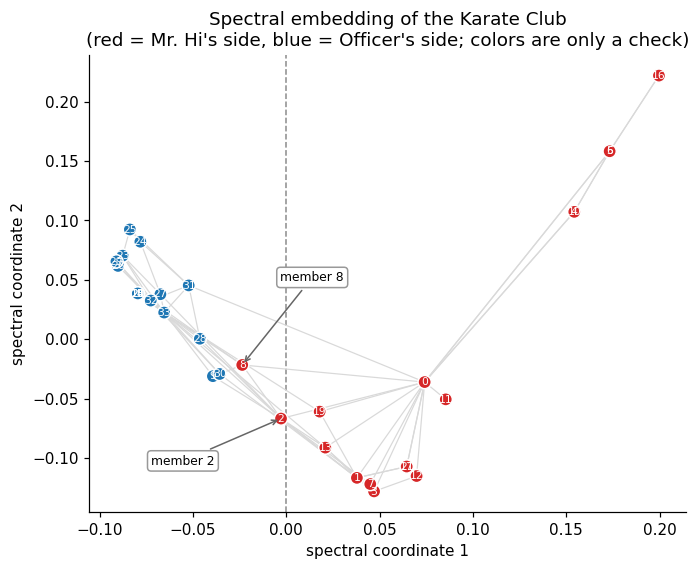

In [ ]:
from sklearn.manifold import SpectralEmbedding

emb = SpectralEmbedding(n_components=2, affinity="precomputed", random_state=0).fit_transform(A)
if emb[0, 0] < 0:                              # orientation is arbitrary; put Mr. Hi (member 0) on the right
    emb[:, 0] *= -1

fig, ax = plt.subplots(figsize=(7, 5.4))
for u, v in K.edges:
    ax.plot(*zip(emb[u], emb[v]), color="0.85", lw=0.8, zorder=1)
ax.scatter(emb[:, 0], emb[:, 1], c=np.where(truth == 1, "tab:red", "tab:blue"), s=75, zorder=2, edgecolors="white")
for i in range(n):
    ax.annotate(str(i), emb[i], fontsize=7, ha="center", va="center", zorder=3, color="white")
ax.axvline(0, color="0.55", ls="--", lw=1, zorder=0)          # the dividing line at zero
offsets = {2: (-85, -30), 8: (25, 55)}
for i in wrong:
    ax.annotate(f"member {i}", emb[i], textcoords="offset points", xytext=offsets.get(i, (20, 20)), fontsize=8,
                bbox=dict(boxstyle="round", fc="white", ec="0.6"), arrowprops=dict(arrowstyle="->", color="0.4"))
ax.set_xlabel("spectral coordinate 1"); ax.set_ylabel("spectral coordinate 2")
ax.set_title("Spectral embedding of the Karate Club\n(red = Mr. Hi's side, blue = Officer's side; colors are only a check)")
plt.show()

**Reading the picture.** The dashed line is the dividing line at zero. Members to its left have negative Fiedler coordinates and members to its right have positive ones, so the sign of the coordinate splits the club into two sides. The two boxed members belong to the instructor's side, but their coordinates fall just below zero, so the sign puts them on the wrong side. Both sit almost on the line. The club unrolls along a curve with its two halves at opposite ends, and the members near the middle are visibly *between* things.

So the Fiedler coordinate helps identify group membership, and it carries two pieces of information in one number:

- **The sign** says which of two groups a member belongs to.
- **The size** says how firmly. Members far from zero sit deep inside a group, while members near zero sit near the boundary and could go either way.

It comes from the connections alone, and it gives a two-way split. (For three or more groups, we use more eigenvectors, which Part 7 does.) That is knowledge discovery in a geometric frame: we did not tell the algorithm what the groups were, or even that there were groups. We asked for the smoothest numbering the network allows, and the groups appeared as regions.

*A side note on UMAP.* UMAP is a method for drawing many-feature data in two dimensions so that points that were close stay close. It builds a nearest-neighbor graph of the points and then starts its picture with a spectral embedding of exactly this kind. You will build such a graph in Part 7.

> **Big idea.** Give members numbers that change as little as possible across friendships. The smoothest numbering splits the network into its sides, and the members near zero are the ones on the boundary.

---
## Part 6 — Community detection: a label that summarizes geometry

The Fiedler vector gave us a *coordinate*. Most software instead hands you a *label*: "member 5 belongs to community 2." The most widely used method is **Louvain** (Blondel et al., 2008, from the University of Louvain). It works by trial and error: start with every member in a group of their own, move each member to whichever neighbor's group makes the groups tighter, merge groups into bigger units, and repeat. (The score it improves is called *modularity*, which compares how much of the network's connections fall inside groups against what you would expect from random wiring.) It is guess-refine-repeat once more.

Louvain is a second, independent way to find groups. Iit decides for itself how many groups there are. Let's see what it finds.

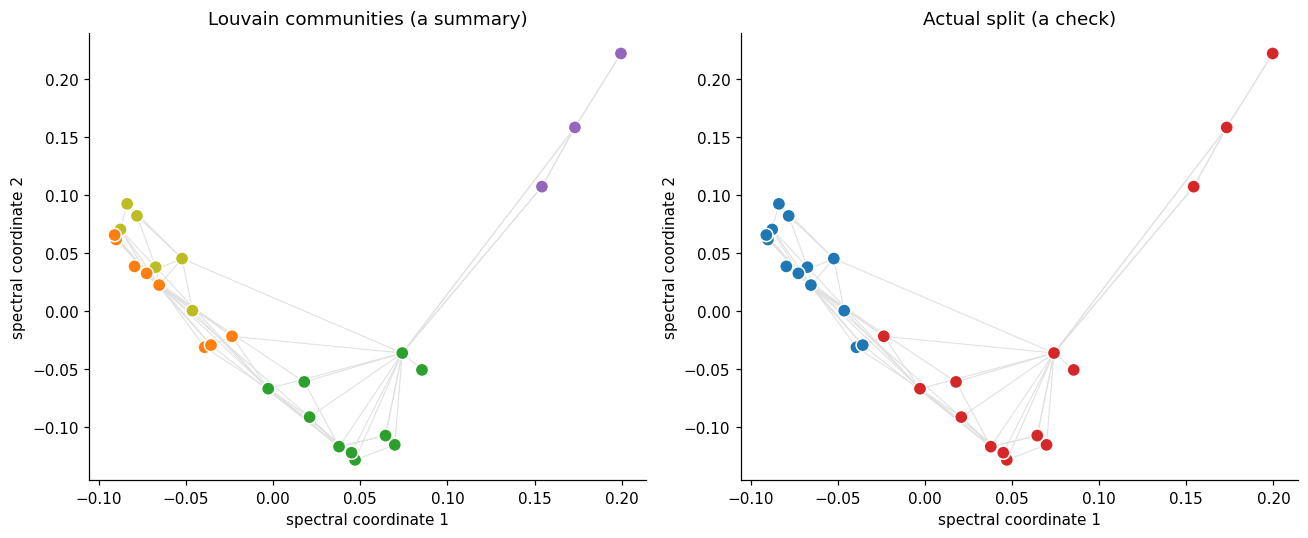

actual side        Mr. Hi  Officer
Louvain community                 
0                      11        0
1                       5        0
2                       1       11
3                       0        6
members whose actual side differs from their Louvain community's majority side: [8]


In [ ]:
def to_labels(communities, n):
    # turn a list of groups (sets of members) into one group number per member
    lab = np.zeros(n, dtype=int)
    for c, members in enumerate(communities):
        for m in members:
            lab[m] = c
    return lab

louv = to_labels(sorted(nx.community.louvain_communities(K, seed=0), key=min), n)
palette = ["tab:green", "tab:purple", "tab:orange", "tab:olive", "tab:cyan", "tab:brown"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
panels = [([palette[l] for l in louv], "Louvain communities (a summary)"),
          (np.where(truth == 1, "tab:red", "tab:blue"), "Actual split (a check)")]
for ax, (colors, title) in zip(axes, panels):
    for u, v in K.edges:
        ax.plot(*zip(emb[u], emb[v]), color="0.88", lw=0.7, zorder=1)
    ax.scatter(emb[:, 0], emb[:, 1], c=colors, s=75, zorder=2, edgecolors="white")
    ax.set_title(title); ax.set_xlabel("spectral coordinate 1"); ax.set_ylabel("spectral coordinate 2")
plt.tight_layout(); plt.show()

print(pd.crosstab(pd.Series(louv, name="Louvain community"), pd.Series(np.where(truth == 1, "Mr. Hi", "Officer"), name="actual side")))

majority = {c: int(truth[louv == c].mean() > 0.5) for c in set(louv)}
odd = [i for i in nodes if truth[i] != majority[louv[i]]]
print("members whose actual side differs from their Louvain community's majority side:", odd)

**Note: Some members sit at exactly the same spot, so their points are stacked.**

Louvain found four groups, but the club really split into two. The two pictures use the same map (the spectral embedding from Part 5), colored two ways. On the left, Louvain's four groups tile the map like four small regions. On the right, the real split colors it in two big halves.

**Reading the table.** Each row is a group that Louvain found, numbered 0 to 3. The two columns count how many of that group's members really belonged to the instructor's side (Mr. Hi) and how many to the administrator's side (Officer):

| Louvain group | From Mr. Hi's side | From the Officer's side |
|---|---|---|
| 0 | 11 | 0 |
| 1 | 5 | 0 |
| 2 | 1 | 11 |
| 3 | 0 | 6 |

- Groups 0 and 1 hold only members from the instructor's side.
- Group 3 holds only members from the administrator's side.
- Group 2 is almost entirely the administrator's side, plus one member from the instructor's side. The last line, `[8]`, names that member: member 8, the same boundary member we met in Part 5.

So Louvain's four groups fit inside the two real sides, like four small teams inside two larger ones. Louvain and the real split are not competing answers. They describe the same network at different levels of detail.

**One caution.** Louvain makes random choices along the way, so a different starting seed can give a slightly different answer. Here is a quick look.

In [ ]:
for seed in range(5):
    groups = nx.community.louvain_communities(K, seed=seed)
    print(f"seed {seed}: {len(groups)} groups, modularity {nx.community.modularity(K, groups):.3f}")

seed 0: 4 groups, modularity 0.420
seed 1: 4 groups, modularity 0.419
seed 2: 4 groups, modularity 0.419
seed 3: 4 groups, modularity 0.415
seed 4: 4 groups, modularity 0.415


The number of groups is steady here, but the scores wobble a little, and on other networks the groups themselves can shift. So a careful analysis states which seed was used. AI-generated code almost never sets one.

What neither label tells you is which members sit firmly inside a group and which sit near the edge. The spectral coordinates show that.

> **Working rule.** A group label tells you which group a member was put in, but not how firmly they belong. When software gives you a label, ask which members were close to the edge. Those are often the most interesting cases.

---
## Part 7 — Two ways graphs get made from data

So far the graph was given to us. Often we have to *build* it, and there are two different ways to do that, which produce two different kinds of graph: a graph of **observations** (the rows become nodes) and a graph of **variables** (the columns become nodes).



### 7.1 Observations → graph: connect each point to its nearest neighbors

Take the Iris flowers. Each flower is already a point in 4-D (four measurements). Connect every flower to its 5 nearest neighbors and you have converted a cloud of points into a graph whose nodes are **observations**. (UMAP builds a graph of this kind internally.) Then apply the Laplacian tools from Part 5. We will use the species labels only at the end, as a check.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import kneighbors_graph

X_iris, species = load_iris(return_X_y=True)
Ak = kneighbors_graph(X_iris, n_neighbors=5, mode="connectivity", include_self=False)
Ak = Ak.maximum(Ak.T).toarray()                       # symmetrize: connect if either is a neighbor of the other
Gk = nx.from_numpy_array(Ak)

comps = sorted(len(c) for c in nx.connected_components(Gk))
print("connected components (sizes):", comps)

Lk = np.diag(Ak.sum(axis=1)) - Ak
ev_k, vec_k = np.linalg.eigh(Lk)
print("bottom Laplacian eigenvalues:", np.round(ev_k[:6], 4) + 0.0)

# a check-for that AI-generated code often misses: many graph functions assume ONE connected component
try:
    nx.diameter(Gk)
except nx.NetworkXError as e:
    print("\nnx.diameter fails on this graph ->", e)

connected components (sizes): [50, 100]
bottom Laplacian eigenvalues: [0.     0.     0.0673 0.212  0.2757 0.4704]

nx.diameter fails on this graph -> Found infinite path length because the graph is not connected


**Reading the output.** The graph has two separate pieces, one of 50 flowers and one of 100. The Laplacian reports **two zero eigenvalues**, which matches: the number of zero eigenvalues counts the separate pieces. Geometry told us the flower cloud has a gap in it before we asked for any clusters.

The failure of `nx.diameter` is a real hazard: distance-based functions assume one connected piece, and on a graph like this they raise an error.

We know the flowers come in three species, so we ask for three groups. We take the three smoothest numberings (the bottom three eigenvectors) as each flower's coordinates and cluster in that space.

ARI vs species: 0.759
species (check only)   0   1   2
spectral region                 
0                      0  50  14
1                     50   0   0
2                      0   0  36
flowers outside their region's majority species: 14


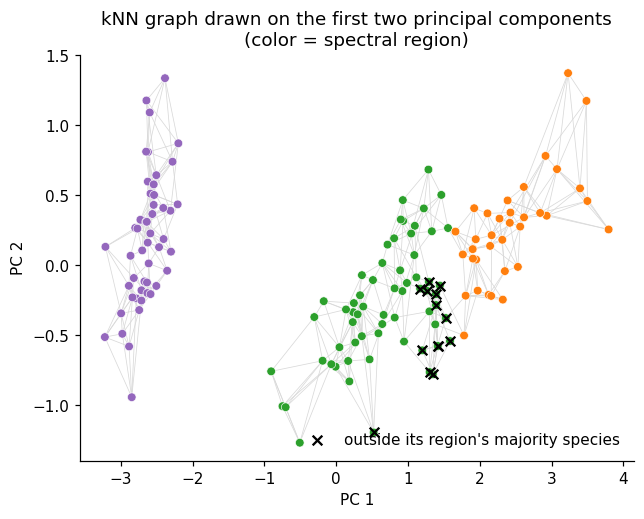

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

coords = vec_k[:, :3]                                         # bottom-3 eigenvectors as coordinates
lab_k = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(coords)
print("ARI vs species:", round(adjusted_rand_score(species, lab_k), 3))
print(pd.crosstab(pd.Series(lab_k, name="spectral region"), pd.Series(species, name="species (check only)")))

# check only: which flowers fall in a region dominated by a different species?
region_species = pd.crosstab(lab_k, species).values.argmax(axis=1)
off = species != region_species[lab_k]
print("flowers outside their region's majority species:", int(off.sum()))

# draw the kNN graph on the first two principal components, colored by spectral region
xy2 = PCA(n_components=2).fit_transform(X_iris)
region_colors = np.array(["tab:green", "tab:purple", "tab:orange"])[lab_k]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
for u, v in zip(*np.nonzero(np.triu(Ak))):
    ax.plot(*zip(xy2[u], xy2[v]), color="0.85", lw=0.5, zorder=1)
ax.scatter(xy2[:, 0], xy2[:, 1], c=region_colors, s=32, zorder=2, edgecolors="white", linewidths=0.4)
ax.scatter(xy2[off, 0], xy2[off, 1], marker="x", c="black", s=40, zorder=3, label="outside its region's majority species")
ax.legend(frameon=False, loc="lower right")
ax.set_title("kNN graph drawn on the first two principal components\n(color = spectral region)")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.show()

Note: ARI = adjusted Rand index. It answers one question: how well do two different groupings of the same items agree?

**Reading the output.** The table shows each spectral region (rows) against the true species (columns). The spectral regions isolate *setosa* exactly (region 1 holds all 50 and nothing else), and separate most of *versicolor* from *virginica*. The marked flowers (black x's) are the 14 virginica that landed in the versicolor region, and they sit where the two species' clouds overlap, the same in-between zone we saw for members 2 and 8 in the karate club. **ARI** (the adjusted Rand index) compares two groupings: 1 means identical, and about 0 means no better than chance. No species labels were used to build the graph, the coordinates, or the clusters. They only graded the result.

### 7.2 Variables → graph: connect features that depend on each other

The second way turns the **columns** into nodes. The naive approach is to connect two variables if they are correlated, but correlation is a poor edge, as this example shows. We build five variables ourselves, so we know the true structure. There are two separate chains. In the first, `x1` drives `x2`, and `x2` drives `x3`. In the second, `x4` drives `x5`. The two chains are unrelated to each other.

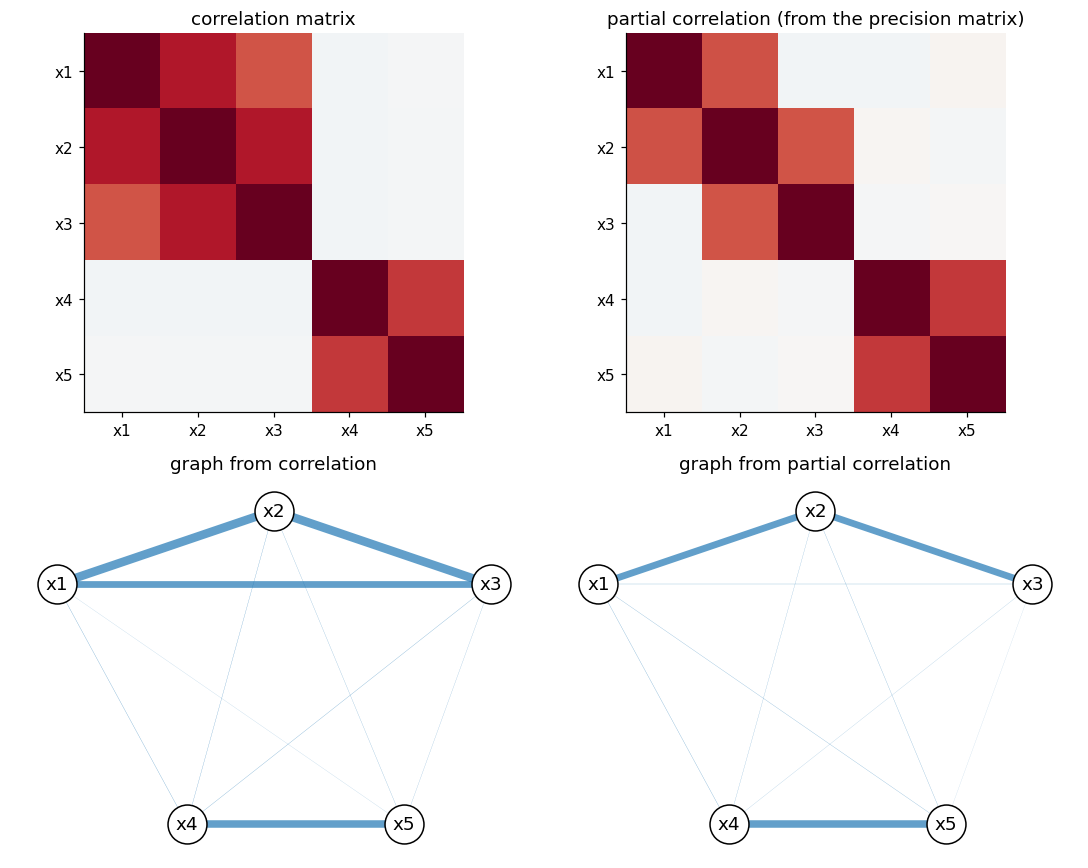

corr(x1, x3)    = 0.631   <- looks like a strong tie
partial(x1, x3) = -0.025   <- ~0: x1 and x3 only relate through x2


In [ ]:
rng = np.random.default_rng(0)
m = 5000
x1 = rng.normal(size=m)
x2 = 0.8 * x1 + rng.normal(scale=0.6, size=m)
x3 = 0.8 * x2 + rng.normal(scale=0.6, size=m)
x4 = rng.normal(size=m)
x5 = 0.7 * x4 + rng.normal(scale=0.7, size=m)
Xv = np.column_stack([x1, x2, x3, x4, x5])
names = ["x1", "x2", "x3", "x4", "x5"]

corr = np.corrcoef(Xv.T)
P_ = np.linalg.inv(np.cov(Xv.T))                       # the precision matrix
d_ = np.sqrt(np.diag(P_))
partial = -P_ / np.outer(d_, d_)                       # partial correlation: dependence after accounting for the others
np.fill_diagonal(partial, 1.0)

def draw_dependence(M_, ax, title):
    G_ = nx.complete_graph(5)
    pos_ = {0: (0, 1), 1: (1, 1.4), 2: (2, 1), 3: (0.6, -0.3), 4: (1.6, -0.3)}
    widths = [7 * abs(M_[i, j]) for i, j in G_.edges]          # edge thickness = strength; no cutoff, no yes/no
    nx.draw_networkx_edges(G_, pos_, ax=ax, width=widths, edge_color="tab:blue", alpha=0.7)
    nx.draw_networkx_nodes(G_, pos_, ax=ax, node_color="white", edgecolors="black", node_size=650)
    nx.draw_networkx_labels(G_, pos_, labels=dict(enumerate(names)), ax=ax)
    ax.set_title(title); ax.axis("off")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1);     axes[0, 0].set_title("correlation matrix")
axes[0, 1].imshow(partial, cmap="RdBu_r", vmin=-1, vmax=1);  axes[0, 1].set_title("partial correlation (from the precision matrix)")
for a in axes[0]:
    a.set_xticks(range(5)); a.set_xticklabels(names); a.set_yticks(range(5)); a.set_yticklabels(names)
draw_dependence(corr, axes[1, 0], "graph from correlation")
draw_dependence(partial, axes[1, 1], "graph from partial correlation")
plt.tight_layout(); plt.show()

print("corr(x1, x3)    =", round(corr[0, 2], 3), "  <- looks like a strong tie")
print("partial(x1, x3) =", round(partial[0, 2], 3), "  <- ~0: x1 and x3 only relate through x2")

Recall that the **precision matrix** is the inverse of the covariance matrix. Where correlation asks "do these two variables move together?", the precision matrix asks "are they *directly* linked, once all the other variables are accounted for?" A zero entry means no direct link, so there is no edge. The code rescales it into **partial correlations**, which run from -1 to 1 like ordinary correlations.

Both sides of the figure answer a question about a *pair* of variables. Here is the answer for the pair `x1` and `x3`:

| | Question about `x1` and `x3` | Answer |
|---|---|---|
| **Left: correlation** | When `x1` is high, is `x3` usually high too? | Yes, strongly (0.63) |
| **Right: partial correlation** | Once we account for all the other variables (mainly `x2`), does knowing `x1` still tell us anything about `x3`? | No (-0.025, essentially zero) |

Think of `x1` as rain, `x2` as mud, and `x3` as dirty shoes. Rain and dirty shoes move together, but only through the mud. Correlation notices that they move together, and partial correlation removes it, because it runs entirely through `x2`. So correlation shows a triangle among `x1`, `x2`, and `x3`, while partial correlation shows a chain (`x1` to `x2` to `x3`), which matches how we built the data.

**Reading the pictures.**

- **Top row (heatmaps).** A dark square means a strong tie and a pale square means almost none. Look at the row for `x1`. On the left, its square with `x3` is fairly dark. On the right, that same square is pale.
- **Bottom row (graphs).** Each line's thickness shows the strength of the tie. On the left there is a thick line between `x1` and `x3`, and on the right that line has disappeared.
- **`x4` and `x5`** look the same on both sides, because they have no middleman.

This is a *different kind of graph* from the karate club. There, nodes were entities and the graph was the data. Here, nodes are features and the graph is a *model* of the data. It is the starting point for Bayesian networks and causal graphs. One limit worth knowing: the right-hand graph shows *who is directly linked* but not *which way* the influence runs. Working out direction is what causal-discovery methods add.

> **Big idea.** There are two kinds of graph. In a graph of observations, nodes are things (Neo4j, RDF, nearest-neighbor graphs). In a graph of variables, nodes are features (precision matrices, causal graphs).

---
## Part 8 — Prompting AI for graph work, and where the bugs hide

Graph code is easy to generate and easy to get subtly wrong. The **structured prompt** from an earlier module earns its keep here. Here is one filled in for a realistic graph task:

```
TASK: Compute PageRank and Louvain communities for a weighted, undirected
      co-occurrence network, and report the 5 highest-PageRank nodes with
      their community.

DATA SHAPE: edge list with columns source, target, weight. weight = number
      of co-occurrences (higher = STRONGER tie). About 80 nodes, undirected,
      possibly more than one connected component.

LIBRARIES: networkx, pandas. No external graph database.

CONSTRAINTS: Use weight as tie strength for PageRank and Louvain. Any function
      that needs a distance (shortest paths, betweenness, closeness) must use
      1/weight, with a comment saying so. Set random seeds. Do not silently
      drop isolated nodes.

CHECK FOR: directed vs. undirected assumption; self-loops; isolated nodes and
      multiple components; whether weight is treated as strength or distance in
      EVERY call; seed dependence of Louvain.
```

Read the CHECK FOR line as a to-do list for reviewing whatever code comes back:

- **Directed or undirected?** Converting one to the other silently changes what "reachable" means.
- **Self-loops and multiple edges.** Does the code collapse parallel edges (as `DiGraph` does)? Should a self-loop count?
- **Isolated nodes and separate pieces.** Functions like `nx.diameter` raise errors on graphs in more than one piece, as we saw in Part 7.
- **Seeds.** Louvain and layouts use random choices, as we saw in Part 6.
- **Strength or distance?** This is the most common quiet bug, and it is worth seeing happen.

### The number on an edge can mean two opposite things

Sometimes the number on an edge means **strength** (bigger means a closer tie). Sometimes it means **distance** (bigger means farther apart). Some functions expect one, and some expect the other, and the code will happily run either way. Here is a tiny example. Three friends, and the number on each connection is how many times a pair has hung out, so **a bigger number means a closer friendship**:

- Ann and Ben: 9 hangouts (close friends)
- Ben and Cy: 9 hangouts (close friends)
- Ann and Cy: 1 hangout (barely know each other)

Ann and Cy want to know their closest connection. The function `shortest_path` acts like a GPS. It reads the number on each connection as a **length** (miles) and looks for the route with the fewest total miles. Our numbers are not miles. They are hangouts, and a big number of hangouts should count as a *short* distance. The GPS reads it the opposite way: 9 hangouts becomes a 9-mile road, and 1 hangout becomes a 1-mile road. Let's see what it does.

In [ ]:
friends = nx.Graph()
friends.add_edge("Ann", "Ben", weight=9)    # hung out 9 times: a close tie
friends.add_edge("Ben", "Cy",  weight=9)    # hung out 9 times: a close tie
friends.add_edge("Ann", "Cy",  weight=1)    # hung out once: barely know each other

# the tempting call: hand the number straight to a distance function
print("weights used as distances:     ", nx.shortest_path(friends, "Ann", "Cy", weight="weight"))

# the fix: convert strength into distance first (big strength -> small distance)
for u, v, d in friends.edges(data=True):
    d["distance"] = 1 / d["weight"]
print("weights converted (1 / weight):", nx.shortest_path(friends, "Ann", "Cy", weight="distance"))

weights used as distances:      ['Ann', 'Cy']
weights converted (1 / weight): ['Ann', 'Ben', 'Cy']


**Reading the output.** With the raw numbers, the GPS sends Ann straight to Cy, along their weakest tie, because it sees a 1-mile road instead of two 9-mile roads. After we convert each strength into a distance, the route goes through Ben, which is the sensible answer: Ann and Cy are best connected through their mutual close friend.

The conversion is `1 ÷ number`, so the order of the sizes reverses:

| Tie | Hangouts (strength) | 1 ÷ hangouts (distance) | What it means |
|---|---|---|---|
| Ann and Ben | 9 | 0.11 | very close, so a short distance |
| Ben and Cy | 9 | 0.11 | very close, so a short distance |
| Ann and Cy | 1 | 1.0 | barely know each other, so a long distance |

| Route from Ann to Cy | Ties used | Length with the raw numbers | Length with 1 ÷ number |
|---|---|---|---|
| Direct | Ann–Cy | 1 | 1 |
| Through Ben | Ann–Ben, Ben–Cy | 9 + 9 = 18 | 0.11 + 0.11 = 0.22 |

The route with the smaller total wins in each case: the direct route for the raw numbers (1 beats 18), and the route through Ben after conversion (0.22 beats 1). Now the same mistake in a second function.

In [ ]:
print("betweenness, weights used as distances:     ", nx.betweenness_centrality(friends, weight="weight"))
print("betweenness, weights converted (1 / weight):", nx.betweenness_centrality(friends, weight="distance"))

betweenness, weights used as distances:      {'Ann': 0.0, 'Ben': 0.0, 'Cy': 0.0}
betweenness, weights converted (1 / weight): {'Ann': 0.0, 'Ben': 1.0, 'Cy': 0.0}


**The facts about the friendships never change.** In both runs, Ann and Cy have hung out once and each has hung out with Ben nine times. What changes is which route the function reports, because it reads the same numbers two different ways.

- **Ann and Cy hardly know each other.** That is true in both runs.
- **Ann and Cy don't know each other well through Ben.** What is true is that the best *chain of friendships* linking them runs through Ben, because both are close to him.

The question the code asks is: *what is the best route from Ann to Cy?* Think of Ann wanting to reach Cy. She could approach Cy directly, but they barely know each other. Or she could go through Ben, who is close to both of them. The sensible answer is to go through Ben.

| | How the function reads the numbers | Route it picks | Sensible? |
|---|---|---|---|
| **First run** | As lengths: a big number means far | Ann → Cy directly (the weakest tie) | No |
| **Second run** | As friendship strengths, after we convert them to distances | Ann → Ben → Cy (two strong ties) | Yes |

So the first run makes a mistake, and it isn't a different opinion about Ann and Cy. It sees the 1-hangout tie as a short road and the 9-hangout ties as long roads, and picks the "short" one. The second run fixes that by converting the numbers, so the close friendships count as short distances.



Betweenness, from Part 0, measures how often someone sits on other people's shortest routes. With the raw numbers, the shortest route from Ann to Cy skips Ben, so Ben scores 0 and nobody counts as a go-between. With the converted distances, that route goes through Ben, so he scores 1.0, the maximum: the only pair of other people is Ann and Cy, and their route goes through him. Ben really is the go-between, and the mistaken version says he connects nobody.

Nothing crashed and no warning appeared. The code ran and produced plausible-looking output that answered the wrong question. That is why the prompt template has a CHECK FOR line. You don't need to memorize which function wants which. You need to remember to ask: **"in this call, does a big number mean close or far?"**

> **Big idea.** Graph code fails quietly. Give the AI the shape of your data (what the number means), and check its work against a case small enough to verify by hand.

---
## Part 9 — Where this leads

**Module 7 (Graph Machine Learning).** Two threads from today become methods there.

- PageRank is a random walk's stationary distribution, meaning the share of time settled at each node. **Node2Vec** uses the *walks themselves* as training data: treat a walk as a "sentence" of nodes and learn embeddings the way word2vec learned them from text in an earlier module. Nodes that appear in similar neighborhoods get similar embeddings.
- The smoothness idea from Part 5 is the idea behind **graph convolutional networks**: they repeatedly average each node's features with its neighbors' features, which smooths signals over the graph.

**Part B (Neo4j).** We will run the same kinds of questions in a graph database: the "within 2 hops" query from Part 1 in Cypher, and PageRank and Louvain through the Graph Data Science library, so we can compare its output with what we computed here.

**Part I of the final project we do together.** The pipeline is Neo4j property graph → Cypher queries → `networkx.DiGraph` → DoWhy. There is no built-in connector between Neo4j and DoWhy, so the translation step is ours, and NetworkX will be the language it is written in.

**Part II of the final project is your individual pot-luck sharing.** Everybody brings a dish of knowledge. I suppose we'll post a sign-up sheet so we all don't bring the same thing.

---
## Key takeaways

1. A graph is **nodes, edges, and properties**. Triples are the minimal form; property graphs let edges carry data.
2. Graph databases exist because multi-hop questions are about **neighborhoods**, and cost should track what you touch, not the size of the dataset. Read benchmark claims critically.
3. **Geometry unifies the toolkit:** adjacency rows are points, shortest paths are a metric (not a flat one), PageRank is a dominant eigenvector, and Laplacian eigenvectors are coordinates that reveal communities.
4. A **label** (a community, a class) is a rounded-off summary of geometry. Ask what the coordinates showed before the rounding.
5. **Two kinds of graph:** graphs of observations (nodes are entities: Neo4j, RDF, nearest-neighbor graphs) and graphs of variables (nodes are features: precision matrices, causal graphs).
6. Graph code fails **quietly**. The structured prompt's CHECK FOR line is your defense: strength or distance, direction, separate pieces, seeds.

---
## Activity and reflection

Add appropriate cells to complete these three tasks and submit your notebook with your written answers.

**1. Find the boundary.** Choose a different network (`nx.davis_southern_women_graph()` is bipartite, so project it first; `nx.les_miserables_graph()` works directly with weights; or use a network of your own). Compute a Laplacian eigenvector embedding as in Part 5, without using any labels. Which one or two nodes sit closest to a boundary? Give a one-paragraph explanation of why, in terms of their connections.

**2. Audit AI code.** Use the structured prompt template to ask an AI assistant for graph-analysis code on your chosen network. Then review the code against the CHECK FOR list in Part 8. Identify at least one assumption it made that you did not specify. Was it correct for your data?

**3. Reflect (150–250 words).** Part 6 argued that a hard label discards information that a coordinate keeps. Give one example from your own field or interests where a category or label hides a meaningful "in between," and say what a coordinate-based view would let you see.

---
### References

- Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics.*
- Breiger, R. L., & Pattison, P. E. (1986). Cumulated social roles: The duality of persons and their algebras. *Social Networks, 8*(3).
- Fiedler, M. (1973). Algebraic connectivity of graphs. *Czechoslovak Mathematical Journal, 23*(2).
- Padgett, J. F., & Ansell, C. K. (1993). Robust action and the rise of the Medici, 1400–1434. *American Journal of Sociology, 98*(6).
- Page, L., Brin, S., Motwani, R., & Winograd, T. (1999). *The PageRank citation ranking: Bringing order to the web.* Stanford InfoLab.
- von Luxburg, U. (2007). A tutorial on spectral clustering. *Statistics and Computing, 17*(4).
- Zachary, W. W. (1977). An information flow model for conflict and fission in small groups. *Journal of Anthropological Research, 33*(4).